# SIFT - Harris
### SIFT - Harris


maximum_filter:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.maximum_filter.html
gaussian_filter:https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.filters.gaussian_filter.html
sobel:https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.sobel.html

matplotlib.patches: https://matplotlib.org/api/patches_api.html

np.where: https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.where.html
np.argwhere: https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.argwhere.html

In [2]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

Number of corners detected: 778


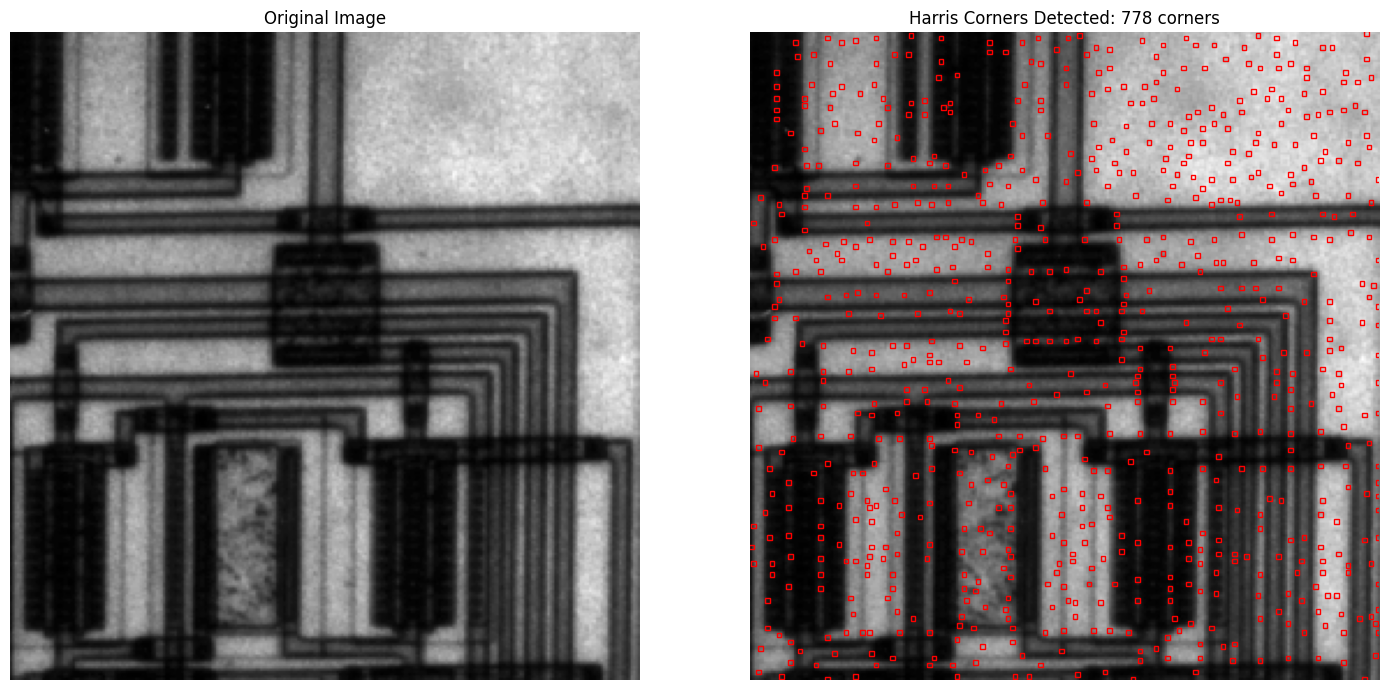

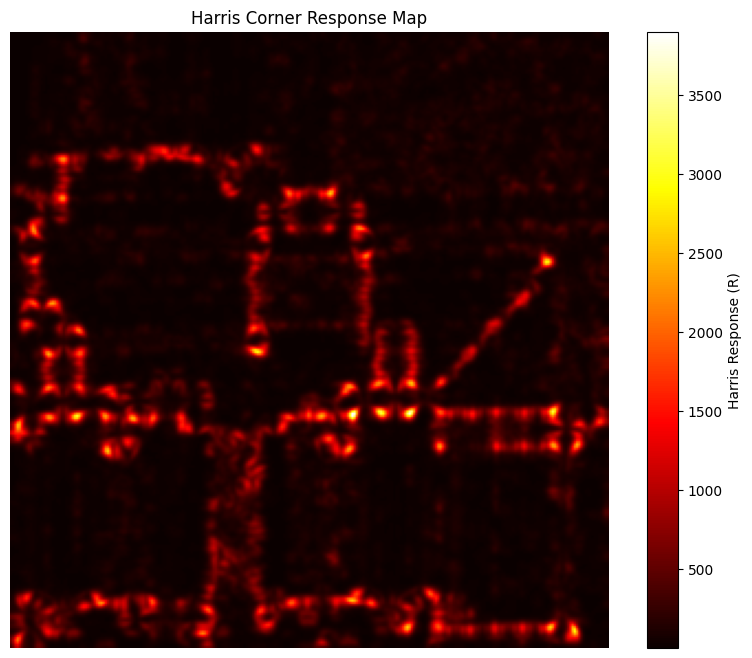

In [3]:
# ============================================================================
# Part 2: Harris Corner Detection
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter, gaussian_filter, sobel
import matplotlib.patches as patches
from skimage import io

eps = 1e-6

# Read the image
img = io.imread('circuit.tif').astype(np.float64)

# TODO 1: Perform gaussian_filter to make the image less noisy
# This preprocessing step reduces noise before computing derivatives
img_smooth = gaussian_filter(img, sigma=1.0)

# TODO 2: Perform sobel to get x-change and y-change
# Sobel operator computes the gradient (derivatives) in x and y directions
Ix = sobel(img_smooth, axis=1)  # x-derivative (horizontal changes)
Iy = sobel(img_smooth, axis=0)  # y-derivative (vertical changes)

# Compute products of derivatives at every pixel
Ixx = Ix * Ix  # Ix^2
Ixy = Ix * Iy  # Ix * Iy
Iyy = Iy * Iy  # Iy^2

# TODO 3-5: Apply Gaussian filter to products of derivatives
# This computes the structure tensor (sum of products in a neighborhood)
sigma = 1.5
Sx2 = gaussian_filter(Ixx, sigma=sigma)  # Sum of Ix^2
Sxy = gaussian_filter(Ixy, sigma=sigma)  # Sum of Ix*Iy
Sy2 = gaussian_filter(Iyy, sigma=sigma)  # Sum of Iy^2

# TODO 6: Calculate Harris corner response R
# R = det(M) / trace(M) = (Sx2*Sy2 - Sxy^2) / (Sx2 + Sy2)
# High R values indicate corners
numerator = (Sx2 * Sy2) - (Sxy ** 2)
denominator = Sx2 + Sy2 + eps  # Add epsilon to avoid division by zero
R = numerator / denominator

# TODO 7: Get local maximum and threshold
# Parameters
threshold = 0.01 * R.max()  # Threshold as percentage of max R value
neighborhood_size = 5  # Size for local maximum filter

# Find local maxima using maximum_filter
local_max = maximum_filter(R, size=neighborhood_size)

# Get corners: points that are local maxima AND above threshold
z = (R == local_max) & (R > threshold)

# Visualize the results
print(f"Number of corners detected: {np.sum(z)}")

# Get indices where corners are detected
indx = np.argwhere(z == True)

# Display results
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# Show original image
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Show image with detected corners
ax[1].imshow(img, cmap='gray')
ax[1].set_title(f'Harris Corners Detected: {len(indx)} corners')
ax[1].axis('off')

# Draw rectangles around detected corners
for ind in indx:
    rect = patches.Rectangle((ind[1]-1, ind[0]-1), 2, 2, 
                            linewidth=1, edgecolor='r', facecolor='none')
    ax[1].add_patch(rect)

plt.tight_layout()
plt.show()

# Display the R value heatmap
plt.figure(figsize=(10, 8))
plt.imshow(R, cmap='hot')
plt.colorbar(label='Harris Response (R)')
plt.title('Harris Corner Response Map')
plt.axis('off')
plt.show()

Keypoints in box.png: 604
Keypoints in box_in_scene.png: 969


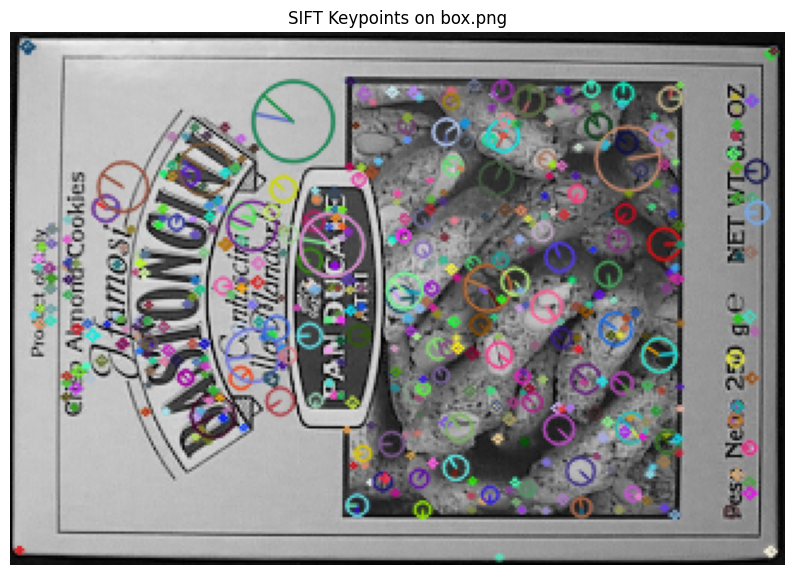

Total matches: 604
Good matches after ratio test: 80


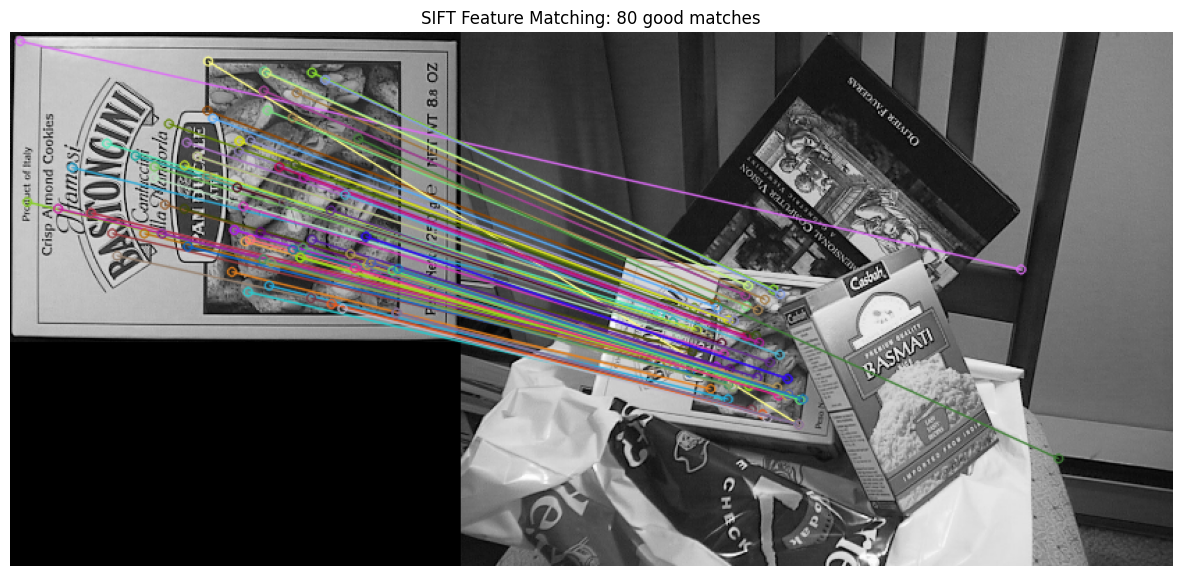


ANSWERS TO LAB QUESTIONS

Part 1: SIFT
----------------------------------------------------------------------

1b. What does the result of the SIFT function mean?

The SIFT function returns two values:
- Keypoints: Special points in the image that are distinctive and scale-invariant
  Each keypoint has: location (x,y), scale (size), orientation (angle)
- Descriptors: 128-dimensional feature vectors describing the local image region
  around each keypoint. These are used for matching.


1d. What does the showkeys result image mean?

The showkeys/drawKeypoints visualization shows:
- Circle position: Location of the keypoint
- Circle size: Scale at which the keypoint was detected
- Line direction: Dominant orientation of the local gradient
These properties make SIFT robust to rotation and scale changes.


3. Matching Process Main Steps:

1. FEATURE DETECTION: Find keypoints in both images using SIFT detector
2. FEATURE DESCRIPTION: Compute descriptors (feature vectors) for each keypoint


In [4]:
# ============================================================================
# Part 1: SIFT (Scale-Invariant Feature Transform)
# ============================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Initialize SIFT detector
sift = cv2.SIFT_create()  # Use cv2.SIFT_create() for OpenCV 4.x

# TODO: Read images
img1 = cv2.imread('box.png', 0)  # Query image (object to find)
img2 = cv2.imread('box_in_scene.png', 0)  # Scene image

# Check if images loaded successfully
if img1 is None or img2 is None:
    print("Error: Could not load images. Make sure 'box.png' and 'box_in_scene.png' exist.")
else:
    # TODO: Find keypoints and descriptors with SIFT
    # detectAndCompute finds keypoints and computes descriptors in one step
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)
    
    print(f"Keypoints in box.png: {len(kp1)}")
    print(f"Keypoints in box_in_scene.png: {len(kp2)}")
    
    # Draw keypoints on the first image
    img1_kp = cv2.drawKeypoints(img1, kp1, None, 
                                flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(img1_kp)
    plt.title('SIFT Keypoints on box.png')
    plt.axis('off')
    plt.show()
    
    # TODO: Construct BFMatcher (Brute Force Matcher)
    # BFMatcher matches descriptors by brute force comparison
    # NORM_L2 is used for SIFT/SURF descriptors
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    
    # Use knnMatch with k=2 to get the 2 best matches for each descriptor
    matches = bf.knnMatch(des1, des2, k=2)
    
    # TODO: Apply Lowe's ratio test to filter good matches
    # Ratio test: if the distance to the closest match is significantly smaller
    # than the distance to the second closest, it's a good match
    good_matches = []
    ratio_threshold = 0.75  # Lowe's paper recommends 0.7-0.8
    
    for match_pair in matches:
        # Check if we got 2 matches (sometimes we might get only 1)
        if len(match_pair) == 2:
            m, n = match_pair  # m is best match, n is second best
            # If best match is significantly better than second best
            if m.distance < ratio_threshold * n.distance:
                good_matches.append([m])
    
    print(f"Total matches: {len(matches)}")
    print(f"Good matches after ratio test: {len(good_matches)}")
    
    # TODO: Draw the matched features
    # flags=4 means cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    img3 = cv2.drawMatchesKnn(img1, kp1, img2, kp2, good_matches, None, 
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    plt.figure(figsize=(15, 10))
    plt.imshow(img3)
    plt.title(f'SIFT Feature Matching: {len(good_matches)} good matches')
    plt.axis('off')
    plt.show()


# ============================================================================
# Explanations for Lab Questions
# ============================================================================

print("\n" + "="*70)
print("ANSWERS TO LAB QUESTIONS")
print("="*70)

print("\nPart 1: SIFT")
print("-" * 70)

print("\n1b. What does the result of the SIFT function mean?")
print("""
The SIFT function returns two values:
- Keypoints: Special points in the image that are distinctive and scale-invariant
  Each keypoint has: location (x,y), scale (size), orientation (angle)
- Descriptors: 128-dimensional feature vectors describing the local image region
  around each keypoint. These are used for matching.
""")

print("\n1d. What does the showkeys result image mean?")
print("""
The showkeys/drawKeypoints visualization shows:
- Circle position: Location of the keypoint
- Circle size: Scale at which the keypoint was detected
- Line direction: Dominant orientation of the local gradient
These properties make SIFT robust to rotation and scale changes.
""")

print("\n3. Matching Process Main Steps:")
print("""
1. FEATURE DETECTION: Find keypoints in both images using SIFT detector
2. FEATURE DESCRIPTION: Compute descriptors (feature vectors) for each keypoint
3. FEATURE MATCHING: Compare descriptors between images using distance metrics
   - Brute Force Matcher compares every descriptor in image1 with all in image2
   - k-NN matching finds k nearest neighbors for each descriptor
4. FILTERING: Apply ratio test to remove ambiguous matches
   - If best match is much better than second best → reliable match
   - If distances are similar → ambiguous, reject it
5. VERIFICATION (optional): Use geometric constraints (RANSAC, homography)

To use other feature extractors:
- Replace cv2.SIFT_create() with:
  * cv2.ORB_create() for ORB (faster, binary descriptors)
  * cv2.AKAZE_create() for AKAZE
  * cv2.BRISK_create() for BRISK
- For binary descriptors (ORB, AKAZE), use cv2.NORM_HAMMING instead of NORM_L2
""")

print("\nPart 2: Harris Corner Detection")
print("-" * 70)
print("""
Harris Corner Detection finds points where gradients change significantly
in multiple directions (corners are distinctive features).

The algorithm:
1. Compute image gradients (Ix, Iy) using Sobel operators
2. Compute products of gradients (Ix², Ix*Iy, Iy²)
3. Apply Gaussian smoothing to get structure tensor components
4. Calculate corner response R = det(M)/trace(M)
   - High R → corner (changes in all directions)
   - Low R → flat region or edge
5. Threshold and non-maximum suppression to get final corners

The Harris response R measures how "corner-like" each pixel is.
""")

print("\n" + "="*70)